<a href="https://colab.research.google.com/github/robotlover2/deeplearning26.08.10/blob/main/8.10_DNN_%EA%B8%B0%EC%B4%88_%EC%8B%AC%EC%9E%A5%EB%B3%91%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 딥러닝 구현하기 – 기초 예제 (학생용 실습본)
# 심장병 발병 예측 (정형 데이터 이진 분류)

---

### 학습 목표

- 딥러닝 모델을 만드는 **6단계 절차**를 순서대로 수행할 수 있다.
- 입력 특성의 **정규화가 왜 필요한지** 실험으로 확인할 수 있다.
- 이진 분류에서 **Sigmoid 출력과 임계값(threshold)** 의 의미를 설명할 수 있다.
- 학습 곡선을 보고 **과적합 여부**를 판단할 수 있다.

### 왜 이미지가 아니라 표(table) 데이터부터 시작하는가

이미지는 픽셀이 수만 개라 모델 내부에서 무슨 일이 일어나는지 보기 어렵다.
행과 열이 눈에 보이는 표 데이터로 시작하면 **입력 → 가중치 → 출력** 의 흐름을 끝까지 따라갈 수 있다.
여기서 익힌 절차가 4차시 이미지 분류, 2일차 CNN, 3일차 YOLO까지 그대로 이어진다.

## 이 노트북 사용법 — 학생용 실습본

이 파일은 **핵심 코드가 빈칸(`____`)으로 비워진 실습본**이다.
수업 중 강사의 설명을 들으며 빈칸을 직접 채워 넣는다.

### 진행 방법

1. 코드 셀 위쪽의 **`채울 곳`** 안내 블록을 먼저 읽는다.
2. 코드 안의 `____` 를 찾아 알맞은 값·함수 이름으로 바꾼다. 각 빈칸에는 `①` `②` 번호가 붙어 있다.
3. `Shift + Enter` 로 셀을 실행한다.

### 실행하면 이런 오류가 난다면

| 오류 메시지 | 원인 |
|---|---|
| `NameError: name '____' is not defined` | 아직 채우지 않은 빈칸이 남아 있다 |
| `SyntaxError` | 빈칸을 지우면서 괄호·따옴표를 함께 지웠다 |

> 빈칸이 아닌 부분은 이미 완성되어 있으니 고치지 않아도 된다.
> 막히면 손을 들거나 채팅으로 알리자. 정답본은 수업 후 배포된다.

## 실행 환경 안내

**Google Colab 기준으로 작성한 노트북이다.**

1. 상단 메뉴 `런타임` → `런타임 유형 변경`
2. 하드웨어 가속기를 `T4 GPU` 로 변경 후 저장
3. 위에서부터 순서대로 셀을 실행한다 (`Shift + Enter`)

> 이 노트북은 CPU에서도 1~2분 내에 학습이 끝난다. GPU는 선택 사항이다.

## 딥러닝 구현 6단계

이번 수업에서 만드는 모든 모델은 아래 여섯 단계를 그대로 따른다.
노트북이 바뀌어도 절차는 동일하므로, 이 틀을 먼저 몸에 익히는 것이 목표다.

| 단계 | 하는 일 | 핵심 코드 |
|---|---|---|
| ① 데이터 로드 | 데이터를 불러와 구조를 확인한다 | `read_csv`, `load_data` |
| ② 전처리 | 스케일 조정 · 분할 · 형태 변환 | `train_test_split`, `/255.0` |
| ③ 모델 구성 | 층을 쌓아 신경망을 정의한다 | `Sequential`, `Dense` |
| ④ 학습 설정 | 손실 함수 · 옵티마이저 · 지표 지정 | `model.compile()` |
| ⑤ 학습 | 데이터를 반복해서 보여준다 | `model.fit()` |
| ⑥ 평가 · 예측 | 처음 보는 데이터로 성능을 확인한다 | `model.evaluate()`, `predict()` |

---
## 1.라이브러리 가져오기

In [3]:

# 이게 가장 중요함 이건 걍 ctrl c ,v
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


---
## 2.① 데이터 로드

미국 UCI 심장병 데이터(Cleveland)를 사용한다. 환자 303명의 검사 수치 13개와
심장병 발병 여부(`target`)로 구성된 표 데이터다.

In [1]:
!gdown 1NbkxEWchJohsa3n-oDqTy5pyoNPeZX2l

Downloading...
From: https://drive.google.com/uc?id=1NbkxEWchJohsa3n-oDqTy5pyoNPeZX2l
To: /content/heart_disease.csv
100% 16.7k/16.7k [00:00<00:00, 41.6MB/s]


In [4]:
df = pd.read_csv('heart_disease.csv')
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [ ]:
# 1순위: TensorFlow 공식 튜토리얼 데이터 / 2순위: UCI 원본
URLS = [
    "https://storage.googleapis.com/download.tensorflow.org/data/heart.csv",
    "https://archive.ics.uci.edu/static/public/45/data.csv",
]

df = None
for u in URLS:
    try:
        df = pd.read_csv(u)
        print("불러오기 성공 :", u)
        break
    except Exception as e:
        print("실패 :", u, "→", type(e).__name__)

assert df is not None, "네트워크 문제로 다운로드에 실패했다. heart.csv를 직접 업로드한 뒤 pd.read_csv('heart.csv')로 불러올 것."

# UCI 원본을 받은 경우 컬럼명을 통일한다
if "num" in df.columns:
    df = df.rename(columns={"num": "target"})
    df["target"] = (df["target"] > 0).astype(int)

print("데이터 크기:", df.shape)
df.head()

불러오기 성공 : https://storage.googleapis.com/download.tensorflow.org/data/heart.csv
데이터 크기: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 33.3+ KB


### 컬럼 의미

| 컬럼 | 의미 | 컬럼 | 의미
|---|---|---|---|
| `age` | 나이 | `exang` | 운동 유발 협심증 여부 |
| `sex` | 성별 | `oldpeak` | 운동 후 ST 하강 |
| `cp` | 흉통 유형 | `slope` | ST 분절 기울기 |
| `trestbps` | 안정 시 혈압 | `ca` | 주요 혈관 수 |
| `chol` | 콜레스테롤 | `thal` | 지중해빈혈 검사 결과 |
| `fbs` | 공복 혈당 > 120 | `target` - 'AHD` | **1 = 심장병 있음 / 0 = 없음** |
| `restecg` | 안정 시 심전도 | | |

AHD
No     164
Yes    139
Name: count, dtype: int64


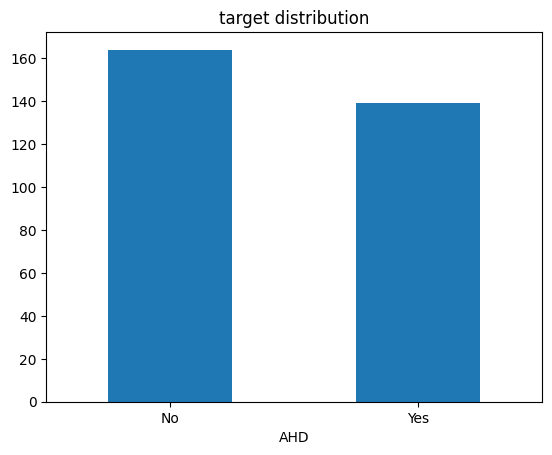

In [ ]:


# 정답(레이블) 분포 확인 — 클래스가 한쪽으로 심하게 치우쳤는지 본다
print(df["AHD"].value_counts())
df["AHD"].value_counts().plot(kind="bar", rot=0, title="target distribution")
#bar로 rot =0 --> 회전 없음
plt.show()

---
## 3.② 전처리

**(1) 문자열 컬럼 처리** — `thal` 컬럼만 문자열이므로 숫자로 바꾼다.     
**(2) 입력/정답 분리** → **(3) train / validation / test 분할** → **(4) 정규화**

> 정규화(표준화)를 하는 이유: `chol`(콜레스테롤)은 200 근처, `oldpeak`는 0~6 범위다.
> 스케일이 크게 다르면 값이 큰 특성이 가중치 갱신을 지배해 학습이 불안정해진다.

In [5]:


# (1) 결측치 제거 후, index를 reset 하기
# 보통은 결측치가 몇개 없으면 채운다

df = df.dropna().reset_index(drop=True)

# (2)-1 문자열(범주형) 컬럼을 레이블 인코딩
df['AHD'] = df['AHD'].map({'Yes':1, 'No':0})

In [ ]:
df.isna().sum()



,0
Age,0
Sex,0
ChestPain,0
RestBP,0
Chol,0
Fbs,0
RestECG,0
MaxHR,0
ExAng,0
Oldpeak,0


In [39]:


# (2)-2 문자열(범주형) 컬럼을 원-핫 인코딩
cat_cols = [c for c in df.columns if df[c].dtype == "object"]
#python이라서 if를 중괄호 없이도 가능함

df_enc = pd.get_dummies(df, columns=cat_cols, dtype="float32")
#df_enc = pd.get_dummies(df, columns=cat_cols, dtype="float32")
df_enc.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD,ChestPain_asymptomatic,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_fixed,Thal_normal,Thal_reversable
0,63,1,145,233,1,2,150,0,2.3,3,0.0,0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,67,1,160,286,0,2,108,1,1.5,2,3.0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,67,1,120,229,0,2,129,1,2.6,2,2.0,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,37,1,130,250,0,0,187,0,3.5,3,0.0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,41,0,130,204,0,2,172,0,1.4,1,0.0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [40]:
# (3) 특성-입력(X)과 타겟-정답(y) 분리 *AHD 만 바꿔주면 됌
X = df_enc.drop("AHD", axis=1).values.astype("float32")
#AHD를 drop한 나머지 데이터들을 넣어줌

y = df_enc['AHD'].values.astype("float32")
# AHD의 데이터만 넣어줌

print("X shape:", X.shape, "/ y shape:", y.shape)

X shape: (297, 18) / y shape: (297,)


In [41]:
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 전체의 20%를 테스트셋으로 떼어 낸다 → 0.2
# ② 클래스 비율을 유지하며 나누려면 무엇을 기준으로 삼아야 할까? (라벨 배열)
# ③ 남은 80% 중 25%를 검증셋으로 (= 전체의 20%)
# └───────────────────────────────────────────────────────────────

# (4) train : validation : test = 6 : 2 : 2
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)          # ① ② 전체의 20%를 테스트용으로 떼어낸다 random_state로 다음번에도 같은 기준으로 사용하도록함

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp) # ③ 테스트용으로 떠어낸 나머지를 가지고 검증용으로 25% 즉 전체의 20을 뗀다

print(f"train {X_train.shape[0]}건 / val {X_val.shape[0]}건 / test {X_test.shape[0]}건")

train 177건 / val 60건 / test 60건


In [42]:
# (5) 정규화 — 반드시 train 기준으로 fit 하고, val/test에는 transform만 적용한다
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 학습셋 : 평균·표준편차를 '계산(fit)하고 동시에 변환(transform)'하는 메서드
# ② 검증·테스트셋 : 학습셋에서 구한 기준으로 '변환만' 하는 메서드
#    (여기서 fit을 다시 하면 테스트 정보가 새어 들어간다 = data leakage)
# └───────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() #전체를 0~1 까지로 변환시킴
X_train = scaler.fit_transform(X_train)   # ① 학습용만 계산해서 변환하고
X_val   = scaler.transform(X_val)     # ② 나머지는 같은 학습용으로 계산한것과 같은 걸로 변환만 시킴
X_test  = scaler.transform(X_test)    # ②

print("정규화 후 train 평균 ≈", X_train.mean().round(3), "/ 표준편차 ≈", X_train.std().round(3))

정규화 후 train 평균 ≈ 0.0 / 표준편차 ≈ 1.0


> **자주 하는 실수** : 전체 데이터에 `fit_transform`을 먼저 적용하면 테스트 데이터의 통계가
> 학습에 새어 들어간다(data leakage). 시험 문제를 미리 본 것과 같으므로 성능이 과대평가된다.

In [ ]:
X_train[0] #3 --> 이렇게 0~1사이의 숫자로 나오게 됌

array([-2.1699846 , -1.3964239 ,  0.43377072, -1.2013723 , -0.44265783,
       -0.99156904,  1.396706  , -0.7161149 ,  0.29601747, -0.9598125 ,
       -0.75815815, -0.2447044 ,  0.95038193, -0.8476123 ,  1.0170953 ,
       -0.61871845, -0.4149523 , -0.30429032], dtype=float32)

---
## 4.③ 모델 구성

입력 특성 개수만큼 뉴런이 들어가고, 출력은 **1개 + Sigmoid** 다.
Sigmoid는 결과를 0~1 사이 확률로 눌러 주므로 "심장병일 확률"로 해석할 수 있다.

In [43]:
n_features = X_train.shape[1] #==18열 즉 특징의 갯수 * 얘만 바꿔서 나머지 다 복사
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 은닉층 활성화 함수 : 음수는 0으로, 양수는 그대로 통과시키는 함수 (문자열)
# ② Dropout 비율 : 학습 때 뉴런의 30%를 끈다 → 0.3
# ③ 출력층 뉴런 수 : 이진 분류이므로 확률 한 개만 필요하다
# ④ 출력층 활성화 함수 : 결과를 0~1 확률로 눌러 주는 함수
# └───────────────────────────────────────────────────────────────

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),      # 입력층
    tf.keras.layers.Dense(32, activation='relu'),      # ① 은닉층 1
    #dropout  중간에 끊어 버림
    tf.keras.layers.Dropout(0.6),                   # ② 과적합 억제
    tf.keras.layers.Dense(16, activation='relu'),      # ① 은닉층 2
    tf.keras.layers.Dense(1, activation='sigmoid')     # ③ ④ 출력층 : 이진 분류면 sigmoid 다중이면 softmax *얘만바꾸면 됌
], name="heart_dnn")

model.summary()

Model: "heart_dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

### 파라미터 수는 어디서 나오는가

첫 은닉층 파라미터 = (입력 특성 수 × 32) + 32(편향).
`model.summary()` 의 숫자와 직접 계산한 값이 같은지 확인해 보자.

---
## 5.④ 학습 설정 (compile)

| 항목 | 선택 | 이유 |
|---|---|---|
| 손실 함수 | `binary_crossentropy` | 정답이 0/1 두 가지인 이진 분류 |
| 옵티마이저 | `Adam` | 학습률을 자동 조절해 안정적으로 수렴 |
| 평가 지표 | `accuracy`, `AUC` | 정확도만으로는 불균형 데이터를 판단하기 어렵다 |

In [44]:
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 학습률 : 가장 무난한 출발값 0.001
# ② 손실 함수 : 정답이 0/1 두 가지인 이진 분류에 쓰는 crossentropy (문자열)
# └───────────────────────────────────────────────────────────────

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),   # ① 학습율 우선 0.001로
    loss='binary_crossentropy',                                                # ②이진 분류 이므로 'binart_crossentropy 사용함
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

---
## 6.⑤ 학습

`EarlyStopping` 은 검증 손실이 더 이상 줄지 않으면 학습을 멈추고
가장 좋았던 시점의 가중치를 복원한다. 과적합을 막는 가장 간단한 장치다.

In [22]:
early = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True, verbose=1)

# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 학습 중 성능을 점검할 데이터 : 검증셋 튜플 (X_val, y_val)
# ② 최대 반복 횟수 : 200  (EarlyStopping이 알아서 멈춘다)
# ③ 한 번에 묶어 계산할 데이터 개수 : 16
# └───────────────────────────────────────────────────────────────

history = model.fit(
    X_train, y_train,
    validation_data=(X_val,y_val),   # ①
    epochs=200,            # ② 최대 반복 횟수 상관 없음
    batch_size=16,        # ③ 한번에 묶어서 계산함
    callbacks=[early],
    verbose=2      # 로그가 길어지므로 생략, 아래 그래프로 확인한다
    #0은 결과만 2는 과정도 보여줘
)
print("실제 학습한 epoch 수:", len(history.history["loss"]))

Epoch 1/200
12/12 - 6s - 475ms/step - accuracy: 0.4520 - auc: 0.4168 - loss: 0.7743 - val_accuracy: 0.4833 - val_auc: 0.4911 - val_loss: 0.7329
Epoch 2/200
12/12 - 0s - 11ms/step - accuracy: 0.5424 - auc: 0.5278 - loss: 0.7050 - val_accuracy: 0.6000 - val_auc: 0.6138 - val_loss: 0.6714
Epoch 3/200
12/12 - 0s - 11ms/step - accuracy: 0.6271 - auc: 0.6608 - loss: 0.6518 - val_accuracy: 0.6333 - val_auc: 0.7115 - val_loss: 0.6278
Epoch 4/200
12/12 - 0s - 11ms/step - accuracy: 0.7062 - auc: 0.7555 - loss: 0.6000 - val_accuracy: 0.7000 - val_auc: 0.7690 - val_loss: 0.5895
Epoch 5/200
12/12 - 0s - 11ms/step - accuracy: 0.7853 - auc: 0.8369 - loss: 0.5546 - val_accuracy: 0.7333 - val_auc: 0.8181 - val_loss: 0.5571
Epoch 6/200
12/12 - 0s - 12ms/step - accuracy: 0.7740 - auc: 0.8462 - loss: 0.5322 - val_accuracy: 0.7500 - val_auc: 0.8421 - val_loss: 0.5270
Epoch 7/200
12/12 - 0s - 11ms/step - accuracy: 0.8192 - auc: 0.8723 - loss: 0.4923 - val_accuracy: 0.7667 - val_auc: 0.8549 - val_loss: 0.501

---
## 7. ⑥ 학습 과정 살펴보기

In [46]:
import matplotlib.pyplot as plt

# history에 저장만 하면 모두다 쓸 수 있음



def plot_history(history, title=""):
    """학습 곡선(손실 · 정확도)을 나란히 그린다."""
    h = history.history
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))

    ax[0].plot(h["loss"], label="train")
    if "val_loss" in h:
        ax[0].plot(h["val_loss"], label="validation")
    ax[0].set_title(f"{title} Loss")
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend(); ax[0].grid(alpha=.3)

    acc_key = "accuracy" if "accuracy" in h else "acc"
    ax[1].plot(h[acc_key], label="train")
    if "val_" + acc_key in h:
        ax[1].plot(h["val_" + acc_key], label="validation")
    ax[1].set_title(f"{title} Accuracy")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Accuracy"); ax[1].legend(); ax[1].grid(alpha=.3)

    plt.tight_layout(); plt.show()

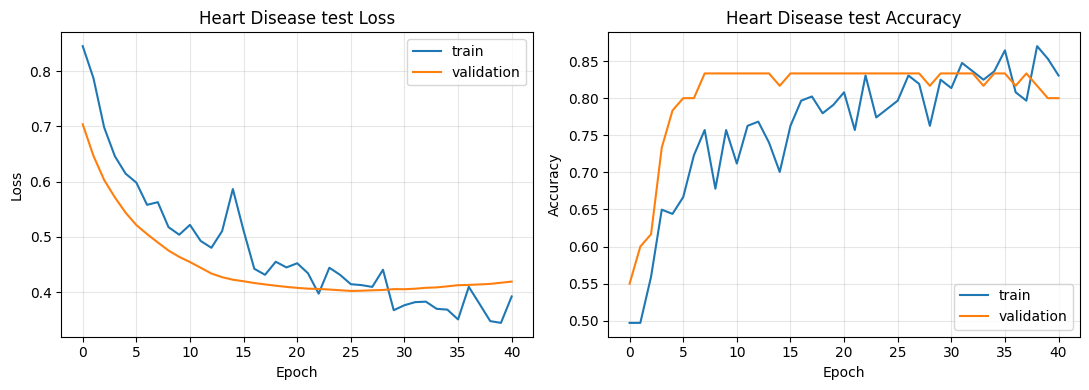

In [47]:
plot_history(history, "Heart Disease test")

### 그래프에서 확인할 것

- 학습 손실과 검증 손실이 **함께** 내려가는가 → 정상
- 학습 손실만 내려가고 검증 손실이 올라가는가 → **과적합**
- 둘 다 높은 곳에서 멈췄는가 → **과소적합**(모델이 너무 작거나 학습이 부족)

---
## 8. 모델 평가 및 예측

In [16]:
loss, acc, auc_score = model.evaluate(X_test, y_test, verbose=0)
print(f"테스트 손실   : {loss:.4f}")
print(f"테스트 정확도 : {acc:.4f}")
print(f"테스트 AUC    : {auc_score:.4f}")

테스트 손실   : 0.3707
테스트 정확도 : 0.8333
테스트 AUC    : 0.9202


In [17]:
# 모델 출력은 '확률'이다. 임계값 0.5를 기준으로 0/1로 바꾼다.
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 판정 임계값 : 확률이 이 값 이상이면 1(심장병)로 본다 → 기본 0.5
# └───────────────────────────────────────────────────────────────

y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)   # ①

for i in range(10):
    print(f"확률 {y_prob[i]:.3f} → 예측 {y_pred[i]} / 실제 {int(y_test[i])}")

확률 0.046 → 예측 0 / 실제 0
확률 0.157 → 예측 0 / 실제 0
확률 0.487 → 예측 0 / 실제 0
확률 0.366 → 예측 0 / 실제 0
확률 0.442 → 예측 0 / 실제 0
확률 0.063 → 예측 0 / 실제 0
확률 0.668 → 예측 1 / 실제 1
확률 0.069 → 예측 0 / 실제 0
확률 0.414 → 예측 0 / 실제 1
확률 0.227 → 예측 0 / 실제 0


In [18]:
cm = confusion_matrix(y_test, y_pred)
print("혼동행렬\n", cm)
print()
print(classification_report(y_test, y_pred, target_names=["정상(0)", "심장병(1)"]))

혼동행렬
 [[29  3]
 [ 7 21]]

              precision    recall  f1-score   support

       정상(0)       0.81      0.91      0.85        32
      심장병(1)       0.88      0.75      0.81        28

    accuracy                           0.83        60
   macro avg       0.84      0.83      0.83        60
weighted avg       0.84      0.83      0.83        60



### 의료 문제에서 어떤 오류가 더 위험한가

- **거짓 음성(FN)** : 심장병 환자를 정상이라 판정 → 치료 시기를 놓친다
- **거짓 양성(FP)** : 정상인을 환자라 판정 → 추가 검사 비용이 든다

의료 진단은 보통 **재현율(Recall)** 을 우선한다. 3일차 안전 탐지 모델에서도 같은 논리가 반복된다.

---
## 9. 임계값을 바꾸면 무엇이 달라지는가

출력 확률을 0/1로 자르는 기준선(임계값)을 낮추면 더 적극적으로 "환자"라 판정한다.
재현율은 오르고 정밀도는 내려간다.

In [ ]:
from sklearn.metrics import precision_score, recall_score

print(f"{'임계값':>6} {'정밀도':>5} {'재현율':>5}")
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (y_prob >= t).astype(int)
    print(f"{t:>8.1f} {precision_score(y_test, p, zero_division=0):>8.3f} "
          f"{recall_score(y_test, p, zero_division=0):>8.3f}")

   임계값   정밀도   재현율
     0.3    0.833    0.893
     0.4    0.875    0.750
     0.5    0.864    0.679
     0.6    0.900    0.643
     0.7    0.889    0.571


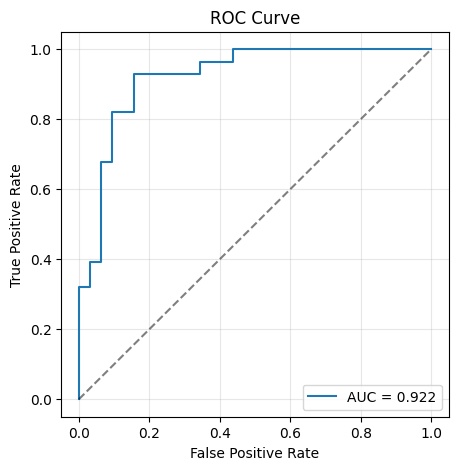

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr, tpr):.3f}")
plt.plot([0, 1], [0, 1], "k--", alpha=.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(); plt.grid(alpha=.3)
plt.show()

---
## 10. 모델 저장하기

In [ ]:
model.save("heart_dnn.keras")
print("저장 완료 : heart_dnn.keras")

# 다시 불러와 동일하게 동작하는지 확인
loaded = tf.keras.models.load_model("heart_dnn.keras")
print("불러온 모델 정확도:", loaded.evaluate(X_test, y_test, verbose=2)[1])

저장 완료 : heart_dnn.keras
2/2 - 1s - 715ms/step - accuracy: 0.8000 - auc: 0.9224 - loss: 0.3787
불러온 모델 정확도: 0.800000011920929


---
## 11. 스스로 해보기

| # | 실험 | 기록할 것 |
|---|---|---|
| 1 | 정규화 코드(4)를 건너뛰고 다시 학습 | 정확도와 수렴 속도가 어떻게 달라지는가 |
| 2 | 은닉층을 `Dense(32)` 하나만 남기기 | 파라미터 수와 성능 변화 |
| 3 | `Dropout(0.3)` → `Dropout(0.6)` | 검증 손실 곡선의 모양 변화 |
| 4 | 학습률 `0.001` → `0.05` | 손실 곡선이 요동치는지 확인 |
| 5 | `EarlyStopping` 제거 후 200 epoch 완주 | 과적합이 나타나는 지점 찾기 |

### 정리

정형 데이터 이진 분류로 **로드 → 전처리 → 구성 → 컴파일 → 학습 → 평가** 여섯 단계를 완주했다.
다음 4차시에서는 입력만 이미지로 바뀔 뿐, 이 절차는 그대로 반복된다.

---
## 12. 실험지

| # | 실험 | 기록할 것 |
|---|---|---|
| 1 | 정규화 코드(4)를 건너뛰고 다시 학습 | 정확도 80--> 0.5 손실: 0.36-> 36.0 |
| 2 | 은닉층을 `Dense(32)` 하나만 남기기 |파라미터 수가 100이상에서 60개로 확 줄면서 정확도는 83으로 으로 높아짐  |
| 3 | `Dropout(0.6)` → `Dropout(0.3)` |검증데이터의loss가 train보다 높아진 것으로 보아 과적합이 더 된 걸 볼 수 있음  |
| 4 | 학습률 `0.001` → `0.05` |손실함수가 요동치는 것을 볼 수 있음  |
| 5 | `EarlyStopping` 제거 후 200 epoch 완주 |과적합이 epcho 20번대 에서 10번대로 한참 전에 일어난 것을 볼 수 있음
  |

3번 전의 그래프

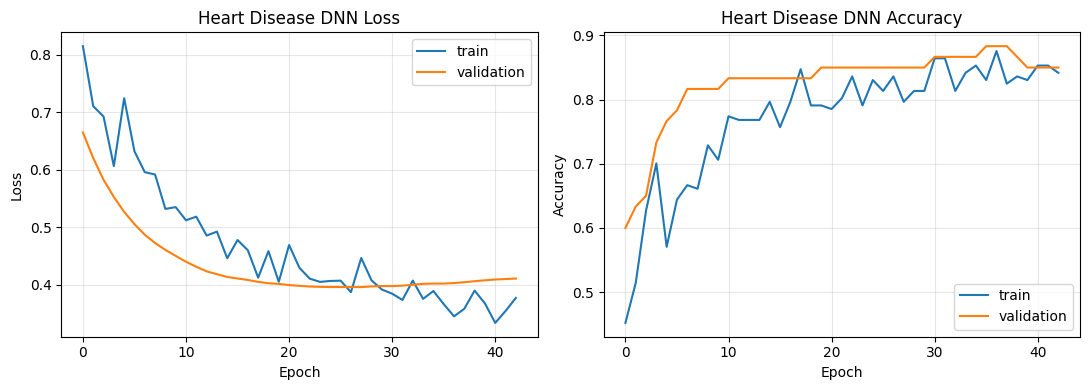


후의 그래프

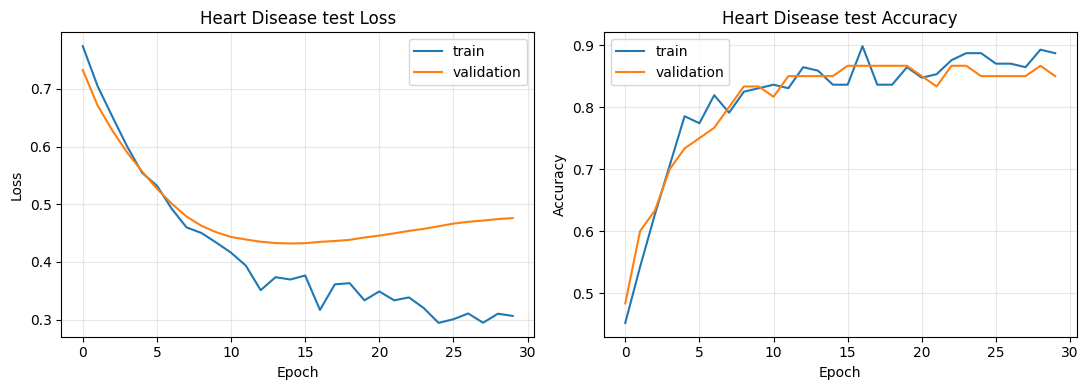


4번 후의 그래프
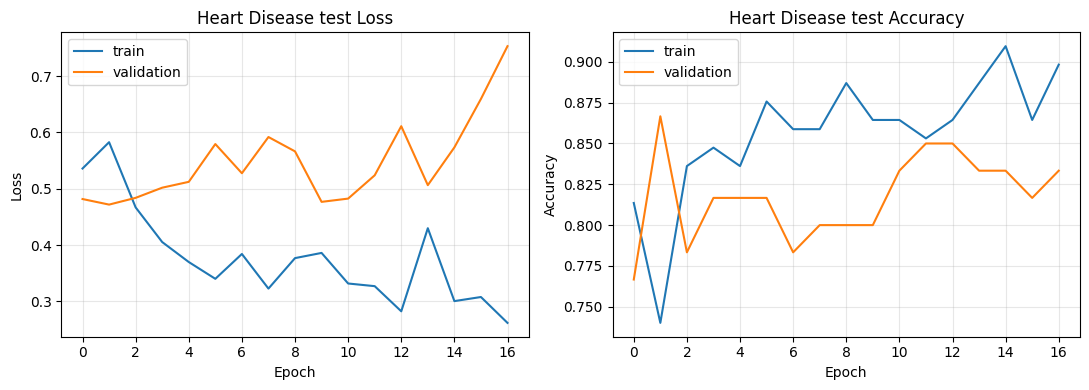


5번 그래프
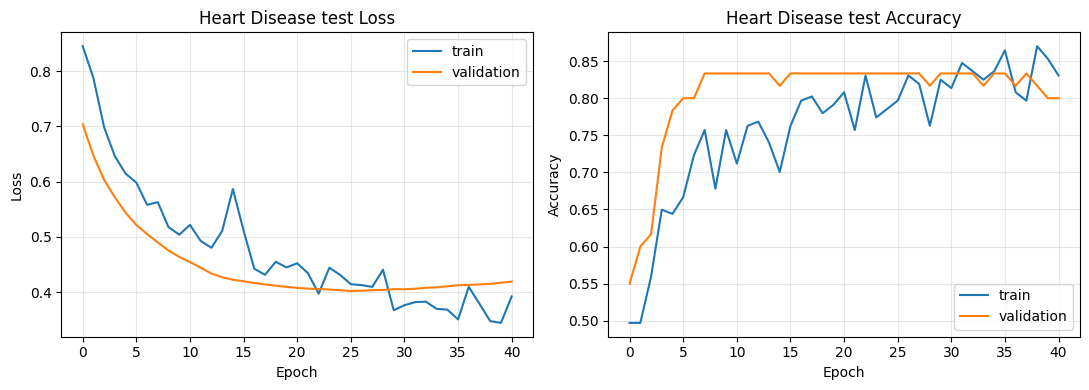

In [ ]:
#1. 정규화 (4) 만 건너뛰고 학습

df = pd.read_csv('heart_disease.csv')

# (1) 결측치 제거 후, index를 reset 하기
# 보통은 결측치가 몇개 없으면 채운다

df = df.dropna().reset_index(drop=True)

# (2)-1 문자열(범주형) 컬럼을 레이블 인코딩
df['AHD'] = df['AHD'].map({'Yes':1, 'No':0})

# (2)-2 문자열(범주형) 컬럼을 원-핫 인코딩
cat_cols = [c for c in df.columns if df[c].dtype == "object"]
#python이라서 if를 중괄호 없이도 가능함

df_enc = pd.get_dummies(df, columns=cat_cols, dtype="float32")
#df_enc = pd.get_dummies(df, columns=cat_cols, dtype="float32")


# (3) 특성-입력(X)과 타겟-정답(y) 분리 *AHD 만 바꿔주면 됌
X = df_enc.drop("AHD", axis=1).values.astype("float32")
#AHD를 drop한 나머지 데이터들을 넣어줌

y = df_enc['AHD'].values.astype("float32")
# AHD의 데이터만 넣어줌

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)          # ① ② 전체의 20%를 테스트용으로 떼어낸다 random_state로 다음번에도 같은 기준으로 사용하도록함

X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp) # ③ 테스트용으로 떠어낸 나머지를 가지고 검증용으로 25% 즉 전체의 20을 뗀다

loaded = tf.keras.models.load_model("heart_dnn.keras")
print("불러온 모델 정확도:", loaded.evaluate(X_test, y_test, verbose=2)[1])

2/2 - 1s - 611ms/step - accuracy: 0.5333 - auc: 0.5000 - loss: 36.0800
불러온 모델 정확도: 0.5333333611488342


In [19]:
#2.은닉층 하나만 남기기
n_features = X_train.shape[1] #==18열 즉 특징의 갯수 * 얘만 바꿔서 나머지 다 복사
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 은닉층 활성화 함수 : 음수는 0으로, 양수는 그대로 통과시키는 함수 (문자열)
# ② Dropout 비율 : 학습 때 뉴런의 30%를 끈다 → 0.3
# ③ 출력층 뉴런 수 : 이진 분류이므로 확률 한 개만 필요하다
# ④ 출력층 활성화 함수 : 결과를 0~1 확률로 눌러 주는 함수
# └───────────────────────────────────────────────────────────────

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),      # 입력층
    tf.keras.layers.Dense(32, activation='relu'),      # ① 은닉층 1
    #dropout  중간에 끊어 버림
    tf.keras.layers.Dropout(0.6),                   # ② 과적합 억제

    tf.keras.layers.Dense(1, activation='sigmoid')     # ③ ④ 출력층 : 이진 분류면 sigmoid 다중이면 softmax *얘만바꾸면 됌
], name="heart_dnn_test")
model.summary()


Model: "heart_dnn_test"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
#3 drop out 0.3 낮추기
n_features = X_train.shape[1] #==18열 즉 특징의 갯수 * 얘만 바꿔서 나머지 다 복사
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 은닉층 활성화 함수 : 음수는 0으로, 양수는 그대로 통과시키는 함수 (문자열)
# ② Dropout 비율 : 학습 때 뉴런의 30%를 끈다 → 0.3
# ③ 출력층 뉴런 수 : 이진 분류이므로 확률 한 개만 필요하다
# ④ 출력층 활성화 함수 : 결과를 0~1 확률로 눌러 주는 함수
# └───────────────────────────────────────────────────────────────

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),      # 입력층
    tf.keras.layers.Dense(32, activation='relu'),      # ① 은닉층 1
    #dropout  중간에 끊어 버림
    tf.keras.layers.Dropout(0.3),                   # ② 과적합 억제
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')     # ③ ④ 출력층 : 이진 분류면 sigmoid 다중이면 softmax *얘만바꾸면 됌
], name="heart_dnn_test")
model.summary()

Model: "heart_dnn_test"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
#4 0.001->0.05
# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 학습률 : 가장 무난한 출발값 0.001
# ② 손실 함수 : 정답이 0/1 두 가지인 이진 분류에 쓰는 crossentropy (문자열)
# └───────────────────────────────────────────────────────────────

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.05),   # ① 학습율 우선 0.001로
    loss='binary_crossentropy',                                                # ②이진 분류 이므로 'binart_crossentropy 사용함
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

In [45]:
#5 early없이 학습


# ┌─ 채울 곳 ─────────────────────────────────────────────────────
# ① 학습 중 성능을 점검할 데이터 : 검증셋 튜플 (X_val, y_val)
# ② 최대 반복 횟수 : 200  (EarlyStopping이 알아서 멈춘다)
# ③ 한 번에 묶어 계산할 데이터 개수 : 16
# └───────────────────────────────────────────────────────────────

history = model.fit(
    X_train, y_train,
    validation_data=(X_val,y_val),   # ①
    epochs=200,            # ② 최대 반복 횟수 상관 없음
    batch_size=16,        # ③ 한번에 묶어서 계산함
    callbacks=[early],
    verbose=2      # 로그가 길어지므로 생략, 아래 그래프로 확인한다
    #0은 결과만 2는 과정도 보여줘
)
print("실제 학습한 epoch 수:", len(history.history["loss"]))

Epoch 1/200
12/12 - 10s - 797ms/step - accuracy: 0.4972 - auc: 0.4521 - loss: 0.8455 - val_accuracy: 0.5500 - val_auc: 0.5692 - val_loss: 0.7039
Epoch 2/200
12/12 - 2s - 166ms/step - accuracy: 0.4972 - auc: 0.5136 - loss: 0.7876 - val_accuracy: 0.6000 - val_auc: 0.6775 - val_loss: 0.6469
Epoch 3/200
12/12 - 0s - 10ms/step - accuracy: 0.5593 - auc: 0.6080 - loss: 0.6982 - val_accuracy: 0.6167 - val_auc: 0.7372 - val_loss: 0.6030
Epoch 4/200
12/12 - 0s - 10ms/step - accuracy: 0.6497 - auc: 0.6765 - loss: 0.6460 - val_accuracy: 0.7333 - val_auc: 0.7952 - val_loss: 0.5716
Epoch 5/200
12/12 - 0s - 11ms/step - accuracy: 0.6441 - auc: 0.7084 - loss: 0.6145 - val_accuracy: 0.7833 - val_auc: 0.8421 - val_loss: 0.5438
Epoch 6/200
12/12 - 0s - 11ms/step - accuracy: 0.6667 - auc: 0.7435 - loss: 0.5983 - val_accuracy: 0.8000 - val_auc: 0.8661 - val_loss: 0.5215
Epoch 7/200
12/12 - 0s - 10ms/step - accuracy: 0.7232 - auc: 0.7793 - loss: 0.5581 - val_accuracy: 0.8000 - val_auc: 0.8867 - val_loss: 0.5